# Black–Scholes Modeling Layer

This notebook implements the modeling lead deliverable for the delta-hedging project. It loads the cleaned project data, computes Black–Scholes theoretical option values and deltas over each option episode, compares implied-volatility and realized-volatility inputs, validates the results, and saves a clean panel for the hedging-simulation teammate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Portable project paths

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data" / "output").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "output"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find data/output from current directory. Current resolved root: {PROJECT_ROOT}"
    )

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Available files:")
for f in sorted(DATA_PATH.iterdir()):
    print(" -", f.name)

Project root: C:\Users\elain\Downloads\5010-Project
Data path: C:\Users\elain\Downloads\5010-Project\data\output
Available files:
 - data_quality_report.md
 - dividends.parquet
 - episodes.parquet
 - option_chain_snapshot.parquet
 - risk_free.parquet
 - stock_intraday_15m.parquet
 - stock_intraday_1h.parquet
 - stock_prices.parquet
 - vix.parquet


## 2. Load cleaned data

Main inputs:
- `episodes.parquet`: the 12 option experiments.
- `stock_prices.parquet`: SPY daily prices and realized-volatility columns.
- `risk_free.parquet`: daily risk-free rate in decimal form.

In [3]:
episodes = pd.read_parquet(DATA_PATH / "episodes.parquet")
prices = pd.read_parquet(DATA_PATH / "stock_prices.parquet")
rf = pd.read_parquet(DATA_PATH / "risk_free.parquet")

print("Episodes:", episodes.shape)
print("Prices:", prices.shape)
print("Risk-free:", rf.shape)

display(episodes.head())
display(prices.head())
display(rf.head())

Episodes: (12, 18)
Prices: (1583, 11)
Risk-free: (1583, 2)


,episode_id,regime,ticker,cp_flag,moneyness,inception_date,S0,strike,expiration,T_days,T_years,iv_inception_vix,iv_inception_vix3m,r_inception,div_amount_in_window,div_ex_dates,pv_div_inception,q_inception
0,SPY_calm_C_ATM,calm,SPY,C,ATM,2021-03-01,389.579987,390.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
1,SPY_calm_C_OTM,calm,SPY,C,OTM,2021-03-01,389.579987,409.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
2,SPY_calm_P_ATM,calm,SPY,P,ATM,2021-03-01,389.579987,390.0,2021-05-28,63,0.250000,0.2335,0.2678,0.00028,1.278,2021-03-19,1.277982,0.013143
3,SPY_stress_C_ATM,stress,SPY,C,ATM,2020-02-03,324.119995,324.0,2020-05-01,62,0.246032,0.1797,0.1804,0.01518,1.406,2020-03-20,1.403313,0.017636
4,SPY_stress_C_OTM,stress,SPY,C,OTM,2020-02-03,324.119995,340.0,2020-05-01,62,0.246032,0.1797,0.1804,0.01518,1.406,2020-03-20,1.403313,0.017636


,date,ticker,open,high,low,close,volume,adj_close,logret,rv_20d,rv_60d
0,2020-01-02,SPY,323.540009,324.890015,322.529999,324.869995,59151200,296.888123,NaN,NaN,NaN
1,2020-01-03,SPY,321.160004,323.640015,321.100006,322.410004,77709700,294.640045,-0.007601,NaN,NaN
2,2020-01-06,SPY,320.489990,323.730011,320.359985,323.640015,55653900,295.764160,0.003808,NaN,NaN
3,2020-01-07,SPY,323.019989,323.540009,322.239990,322.730011,40496400,294.932526,-0.002816,NaN,NaN
4,2020-01-08,SPY,322.940002,325.779999,322.670013,324.450012,68296000,296.504425,0.005315,NaN,NaN


,date,r
0,2020-01-02,0.01495
1,2020-01-03,0.01473
2,2020-01-06,0.01488
3,2020-01-07,0.01500
4,2020-01-08,0.01493


In [4]:
print("Episode columns:")
print(episodes.columns.tolist())

print("Price columns:")
print(prices.columns.tolist())

print("Risk-free columns:")
print(rf.columns.tolist())

Episode columns:
['episode_id', 'regime', 'ticker', 'cp_flag', 'moneyness', 'inception_date', 'S0', 'strike', 'expiration', 'T_days', 'T_years', 'iv_inception_vix', 'iv_inception_vix3m', 'r_inception', 'div_amount_in_window', 'div_ex_dates', 'pv_div_inception', 'q_inception']
Price columns:
['date', 'ticker', 'open', 'high', 'low', 'close', 'volume', 'adj_close', 'logret', 'rv_20d', 'rv_60d']
Risk-free columns:
['date', 'r']


## 3. Prepare daily modeling data

Use the traded SPY `close` price for hedge marking, not the adjusted close. We merge risk-free rates onto trading days only, so SPY prices are not forward-filled into non-trading days.

In [5]:
# Ensure datetime format
prices = prices.copy()
rf = rf.copy()
prices["date"] = pd.to_datetime(prices["date"])
rf["date"] = pd.to_datetime(rf["date"])

data = prices.merge(rf, on="date", how="left")

# Risk-free rates can be filled across available trading rows; do not fill SPY prices into non-trading days.
data["r"] = data["r"].ffill().bfill()

PRICE_COL = "close"
RF_COL = "r"

required_data_cols = ["date", PRICE_COL, RF_COL, "rv_20d", "rv_60d"]
missing_data_cols = [c for c in required_data_cols if c not in data.columns]
if missing_data_cols:
    raise KeyError(f"Missing required columns from merged data: {missing_data_cols}")

display(data.head())

,date,ticker,open,high,low,close,volume,adj_close,logret,rv_20d,rv_60d,r
0,2020-01-02,SPY,323.540009,324.890015,322.529999,324.869995,59151200,296.888123,NaN,NaN,NaN,0.01495
1,2020-01-03,SPY,321.160004,323.640015,321.100006,322.410004,77709700,294.640045,-0.007601,NaN,NaN,0.01473
2,2020-01-06,SPY,320.489990,323.730011,320.359985,323.640015,55653900,295.764160,0.003808,NaN,NaN,0.01488
3,2020-01-07,SPY,323.019989,323.540009,322.239990,322.730011,40496400,294.932526,-0.002816,NaN,NaN,0.01500
4,2020-01-08,SPY,322.940002,325.779999,322.670013,324.450012,68296000,296.504425,0.005315,NaN,NaN,0.01493


## 4. Black–Scholes functions

The formulas include a continuous dividend-yield proxy `q`. The functions are vector-safe and include basic numerical protection near maturity or near-zero volatility.

In [6]:
def bs_d1(S, K, r, q, sigma, tau):
    """Black-Scholes d1 with numerical safeguards."""
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    r = np.asarray(r, dtype=float)
    q = np.asarray(q, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    tau = np.asarray(tau, dtype=float)

    sigma = np.maximum(sigma, 1e-8)
    tau = np.maximum(tau, 1e-8)

    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


def bs_d2(d1, sigma, tau):
    sigma = np.asarray(sigma, dtype=float)
    tau = np.asarray(tau, dtype=float)
    sigma = np.maximum(sigma, 1e-8)
    tau = np.maximum(tau, 1e-8)
    return d1 - sigma * np.sqrt(tau)


def bs_price(S, K, r, q, sigma, tau, option_type="call"):
    """Black-Scholes price for European call or put with continuous dividend yield."""
    d1 = bs_d1(S, K, r, q, sigma, tau)
    d2 = bs_d2(d1, sigma, tau)

    if option_type == "call":
        return S * np.exp(-q * tau) * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    elif option_type == "put":
        return K * np.exp(-r * tau) * norm.cdf(-d2) - S * np.exp(-q * tau) * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def bs_delta(S, K, r, q, sigma, tau, option_type="call"):
    """Black-Scholes delta for European call or put with continuous dividend yield."""
    d1 = bs_d1(S, K, r, q, sigma, tau)

    if option_type == "call":
        delta = np.exp(-q * tau) * norm.cdf(d1)
    elif option_type == "put":
        delta = np.exp(-q * tau) * (norm.cdf(d1) - 1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return np.clip(delta, -1, 1)

## 5. Build Black–Scholes delta panel

This creates one row per option episode, per trading day, per volatility specification. Including both implied and realized volatility lets the project directly compare how volatility input choices change theoretical deltas and downstream hedging performance.

In [7]:
# Core columns in episodes.parquet
EPISODE_ID_COL = "episode_id"
REGIME_COL = "regime"
START_COL = "inception_date"
END_COL = "expiration"
STRIKE_COL = "strike"
CP_COL = "cp_flag"
MONEYNESS_COL = "moneyness"
S0_COL = "S0"
R0_COL = "r_inception"
T_COL = "T_years"
DIV_COL = "div_amount_in_window"

required_episode_cols = [
    EPISODE_ID_COL, REGIME_COL, START_COL, END_COL, STRIKE_COL,
    CP_COL, MONEYNESS_COL, S0_COL, R0_COL, T_COL
]
missing_episode_cols = [c for c in required_episode_cols if c not in episodes.columns]
if missing_episode_cols:
    raise KeyError(f"Missing required columns from episodes: {missing_episode_cols}")

#compare short-tenor implied vol, 3-month implied vol, and historical realized vols.
VOL_METHODS = ["iv_inception_vix", "iv_inception_vix3m", "rv_20d", "rv_60d"]

missing_vol_cols = [c for c in ["iv_inception_vix", "iv_inception_vix3m"] if c not in episodes.columns]
if missing_vol_cols:
    raise KeyError(f"Missing implied-vol columns from episodes: {missing_vol_cols}")

results = []

for vol_method in VOL_METHODS:
    for _, row in episodes.iterrows():
        episode_id = row[EPISODE_ID_COL]
        regime = row[REGIME_COL]
        start = pd.to_datetime(row[START_COL])
        end = pd.to_datetime(row[END_COL])
        K = float(row[STRIKE_COL])
        S0 = float(row[S0_COL])
        option_type = "call" if row[CP_COL] == "C" else "put"

        # Continuous-dividend-yield proxy based on expected dividend cash amount during the option window.
        # If the column is not available or invalid, fall back to q = 0.
        if DIV_COL in episodes.columns and pd.notna(row[DIV_COL]) and row[T_COL] > 0 and S0 > 0:
            q = float(row[DIV_COL]) / S0 / float(row[T_COL])
            q_source = "div_amount_in_window / S0 / T_years"
        else:
            q = 0.0
            q_source = "fallback_zero"

        df = data[(data["date"] >= start) & (data["date"] <= end)].copy()
        if df.empty:
            print(f"Warning: no trading-day data for {episode_id} from {start.date()} to {end.date()}")
            continue

        for _, obs in df.iterrows():
            tau = (end - obs["date"]).days / 365.0
            if tau <= 0:
                continue

            S = float(obs[PRICE_COL])
            r_rate = float(obs[RF_COL]) if pd.notna(obs[RF_COL]) else float(row[R0_COL])

            if vol_method == "iv_inception_vix":
                sigma = row["iv_inception_vix"]
            elif vol_method == "iv_inception_vix3m":
                sigma = row["iv_inception_vix3m"]
            elif vol_method == "rv_20d":
                sigma = obs["rv_20d"]
            elif vol_method == "rv_60d":
                sigma = obs["rv_60d"]
            else:
                raise ValueError(f"Unknown vol_method: {vol_method}")

            if pd.isna(sigma) or sigma <= 0:
                continue

            sigma = float(sigma)
            price = float(bs_price(S, K, r_rate, q, sigma, tau, option_type))
            delta = float(bs_delta(S, K, r_rate, q, sigma, tau, option_type))

            # Keep delta in valid theoretical range and remove tiny floating-point noise near zero.
            delta = float(np.clip(delta, -1.0, 1.0))
            if abs(delta) < 1e-10:
                delta = 0.0

            results.append({
                "episode_id": episode_id,
                "regime": regime,
                "date": obs["date"],
                "S": S,
                "K": K,
                "tau": tau,
                "r": r_rate,
                "q": q,
                "sigma": sigma,
                "bs_price": price,
                "delta": delta,
                "option_type": option_type,
                "cp_flag": row[CP_COL],
                "moneyness": row[MONEYNESS_COL],
                "vol_method": vol_method,
                "q_source": q_source,
                "inception_date": start,
                "expiration": end,
                "S0": S0
            })

bs_panel = pd.DataFrame(results).sort_values(["vol_method", "episode_id", "date"]).reset_index(drop=True)

print("Black-Scholes panel shape:", bs_panel.shape)
display(bs_panel.head())

Black-Scholes panel shape: (2847, 19)


,episode_id,regime,date,S,K,tau,r,q,sigma,bs_price,delta,option_type,cp_flag,moneyness,vol_method,q_source,inception_date,expiration,S0
0,SPY_calm_C_ATM,calm,2021-03-01,389.579987,390.0,0.241096,0.00028,0.013122,0.2335,16.989992,0.506741,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
1,SPY_calm_C_ATM,calm,2021-03-02,386.540009,390.0,0.238356,0.00035,0.013122,0.2335,15.399808,0.479406,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
2,SPY_calm_C_ATM,calm,2021-03-03,381.420013,390.0,0.235616,0.00035,0.013122,0.2335,12.971057,0.432680,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
3,SPY_calm_C_ATM,calm,2021-03-04,376.700012,390.0,0.232877,0.00028,0.013122,0.2335,10.937231,0.389266,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
4,SPY_calm_C_ATM,calm,2021-03-05,383.630005,390.0,0.230137,0.00028,0.013122,0.2335,13.758139,0.451908,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987


## 6. Quality checks

These checks confirm the panel is ready for handoff: no missing model outputs, correct delta ranges, and sensible episode coverage.

In [8]:
print("Shape:", bs_panel.shape)
print("Rows by volatility method:")
display(bs_panel.groupby("vol_method").size().rename("n_rows").to_frame())

print("Missing values:")
display(bs_panel.isna().sum().to_frame("missing_count"))

print("Delta range by option type and volatility method:")
display(
    bs_panel.groupby(["vol_method", "option_type"])["delta"]
    .describe()
)

Shape: (2847, 19)
Rows by volatility method:


,n_rows
vol_method,
iv_inception_vix,741
iv_inception_vix3m,741
rv_20d,741
rv_60d,624


Missing values:


,missing_count
episode_id,0
regime,0
date,0
S,0
K,0
tau,0
r,0
q,0
sigma,0
bs_price,0


Delta range by option type and volatility method:


count      mean       std       min       25%       50%       75%           max
vol_method         option_type                                                                                 
iv_inception_vix   call         494.0  0.329537  0.294446  0.000000  0.009465  0.302847  0.567085  9.999640e-01
                   put          247.0 -0.576541  0.325879 -0.999961 -0.963870 -0.494723 -0.310319 -1.530698e-09
iv_inception_vix3m call         494.0  0.336787  0.283344  0.000000  0.029327  0.326483  0.562621  9.999639e-01
                   put          247.0 -0.576027  0.312627 -0.999961 -0.932776 -0.492196 -0.327421 -1.166364e-07
rv_20d             call         494.0  0.368143  0.299337  0.000000  0.127474  0.272003  0.585284  9.999641e-01
                   put          247.0 -0.513411  0.315327 -0.999961 -0.798464 -0.502336 -0.267798  0.000000e+00
rv_60d             call         416.0  0.359436  0.314924  0.000000  0.077412  0.253607  0.596761  9.999641e-01
                   put          208.0 -0.512943  0.331967 -0.999961 -0.873176 -0.496809 -0.227109  0.000000e+00

In [9]:
# Calls should be between 0 and 1; puts should be between -1 and 0.
bad_calls = bs_panel[
    (bs_panel["option_type"] == "call") &
    ((bs_panel["delta"] < -1e-12) | (bs_panel["delta"] > 1 + 1e-12))
]

bad_puts = bs_panel[
    (bs_panel["option_type"] == "put") &
    ((bs_panel["delta"] < -1 - 1e-12) | (bs_panel["delta"] > 1e-12))
]

print("Bad call rows:", len(bad_calls))
print("Bad put rows:", len(bad_puts))

if len(bad_calls) > 0:
    display(bad_calls.head())
if len(bad_puts) > 0:
    display(bad_puts.head())

Bad call rows: 0
Bad put rows: 0


In [10]:
episode_summary = bs_panel.groupby(["vol_method", "episode_id"]).agg(
    n_days=("date", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    min_tau=("tau", "min"),
    max_tau=("tau", "max"),
    min_delta=("delta", "min"),
    max_delta=("delta", "max"),
    first_price=("bs_price", "first"),
    last_price=("bs_price", "last"),
    mean_sigma=("sigma", "mean")
)

display(episode_summary)

n_days first_date  last_date   min_tau   max_tau     min_delta     max_delta  \
vol_method         episode_id                                                                                        
iv_inception_vix   SPY_calm_C_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096  3.892658e-01  9.999640e-01   
                   SPY_calm_C_OTM         63 2021-03-01 2021-05-27  0.002740  0.241096  2.411383e-01  9.791005e-01   
                   SPY_calm_P_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096 -6.076831e-01 -1.530698e-09   
                   SPY_highvol_C_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  5.430961e-01   
                   SPY_highvol_C_OTM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  3.430716e-01   
                   SPY_highvol_P_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315 -9.999612e-01 -4.534977e-01   
                   SPY_recent_C_ATM       60 2025-10-01 2025-12-24  0.005479  0.235616  3.501367e-01  9.969460e-01   
                   SPY_recent_C_OTM       60 2025-10-01 2025-12-24  0.005479  0.235616  4.385506e-02  4.079310e-01   
                   SPY_recent_P_ATM       60 2025-10-01 2025-12-24  0.005479  0.235616 -6.486290e-01 -2.985381e-03   
                   SPY_stress_C_ATM       62 2020-02-03 2020-04-30  0.002740  0.241096  0.000000e+00  7.155668e-01   
                   SPY_stress_C_OTM       62 2020-02-03 2020-04-30  0.002740  0.241096  0.000000e+00  4.875876e-01   
                   SPY_stress_P_ATM       62 2020-02-03 2020-04-30  0.002740  0.241096 -9.999517e-01 -2.809612e-01   
iv_inception_vix3m SPY_calm_C_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096  4.089553e-01  9.999639e-01   
                   SPY_calm_C_OTM         63 2021-03-01 2021-05-27  0.002740  0.241096  2.750481e-01  9.621893e-01   
                   SPY_calm_P_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096 -5.879936e-01 -1.166364e-07   
                   SPY_highvol_C_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  5.427009e-01   
                   SPY_highvol_C_OTM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  3.790008e-01   
                   SPY_highvol_P_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315 -9.999612e-01 -4.538929e-01   
                   SPY_recent_C_ATM       60 2025-10-01 2025-12-24  0.005479  0.235616  3.717501e-01  9.914866e-01   
                   SPY_recent_C_OTM       60 2025-10-01 2025-12-24  0.005479  0.235616  6.954542e-02  4.233430e-01   
                   SPY_recent_P_ATM       60 2025-10-01 2025-12-24  0.005479  0.235616 -6.270156e-01 -8.444754e-03   
                   SPY_stress_C_ATM       62 2020-02-03 2020-04-30  0.002740  0.241096  0.000000e+00  7.149172e-01   
                   SPY_stress_C_OTM       62 2020-02-03 2020-04-30  0.002740  0.241096  0.000000e+00  4.877524e-01   
                   SPY_stress_P_ATM       62 2020-02-03 2020-04-30  0.002740  0.241096 -9.999517e-01 -2.816108e-01   
rv_20d             SPY_calm_C_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096  3.291647e-01  9.999641e-01   
                   SPY_calm_C_OTM         63 2021-03-01 2021-05-27  0.002740  0.241096  1.478472e-01  9.995269e-01   
                   SPY_calm_P_ATM         63 2021-03-01 2021-05-27  0.002740  0.241096 -6.677842e-01  0.000000e+00   
                   SPY_highvol_C_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  5.430871e-01   
                   SPY_highvol_C_OTM      62 2022-04-01 2022-06-30  0.002740  0.249315  0.000000e+00  3.451556e-01   
                   SPY_highvol_P_ATM      62 2022-04-01 2022-06-30  0.002740  0.249315 -9.999612e-01 -4.535067e-01   
                   SPY_recent_C_ATM       60 2025-10-01 2025-12-24  0.005479  0.235616  3.264192e-01  9.999313e-01   
                   SPY_recent_C_OTM       60 2025-10-01 2025-12-24  0.005479  0.235616  4.919664e-03  3.903330e-01   
                   SPY_rec

## 7. Report resources

In [11]:

import matplotlib.pyplot as plt

FIG_DIR = DATA_PATH / "report_figures"
TABLE_DIR = DATA_PATH / "report_tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

vol_label_map = {
    "iv_inception_vix": "VIX-Implied Volatility",
    "iv_inception_vix3m": "VIX3M-Implied Volatility",
    "rv_20d": "20-Day Realized Volatility",
    "rv_60d": "60-Day Realized Volatility"
}

sample_id = "SPY_calm_C_ATM"
sample = bs_panel[bs_panel["episode_id"] == sample_id].copy()
sample_info = sample.iloc[0]

print("Figure directory:", FIG_DIR)
print("Table directory:", TABLE_DIR)
print("Sample episode used for report figures:", sample_id)


Figure directory: C:\Users\elain\Downloads\5010-Project\data\output\report_figures
Table directory: C:\Users\elain\Downloads\5010-Project\data\output\report_tables
Sample episode used for report figures: SPY_calm_C_ATM


,Volatility Input,Variable,Construction,Time Variation
0,VIX-Implied Volatility,iv_inception_vix,30-day implied volatility fixed at inception,Fixed within episode
1,VIX3M-Implied Volatility,iv_inception_vix3m,3-month implied volatility fixed at inception,Fixed within episode
2,20-Day Realized Volatility,rv_20d,Rolling realized volatility from daily returns,Updated daily
3,60-Day Realized Volatility,rv_60d,Rolling realized volatility from daily returns,Updated daily


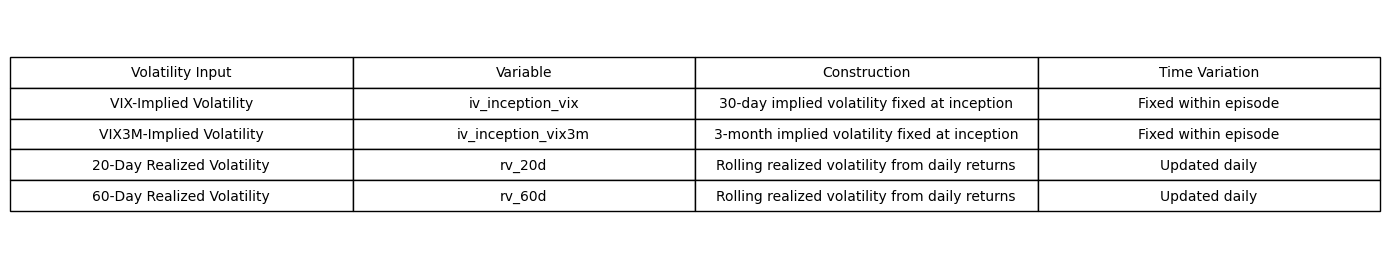

In [12]:

vol_table = pd.DataFrame({
    "Volatility Input": [
        "VIX-Implied Volatility",
        "VIX3M-Implied Volatility",
        "20-Day Realized Volatility",
        "60-Day Realized Volatility"
    ],
    "Variable": [
        "iv_inception_vix",
        "iv_inception_vix3m",
        "rv_20d",
        "rv_60d"
    ],
    "Construction": [
        "30-day implied volatility fixed at inception",
        "3-month implied volatility fixed at inception",
        "Rolling realized volatility from daily returns",
        "Rolling realized volatility from daily returns"
    ],
    "Time Variation": [
        "Fixed within episode",
        "Fixed within episode",
        "Updated daily",
        "Updated daily"
    ]
})

display(vol_table)

vol_table.to_csv(TABLE_DIR / "table_volatility_inputs.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis("off")
tbl = ax.table(
    cellText=vol_table.values,
    colLabels=vol_table.columns,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
plt.tight_layout()
plt.savefig(FIG_DIR / "table_volatility_inputs.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


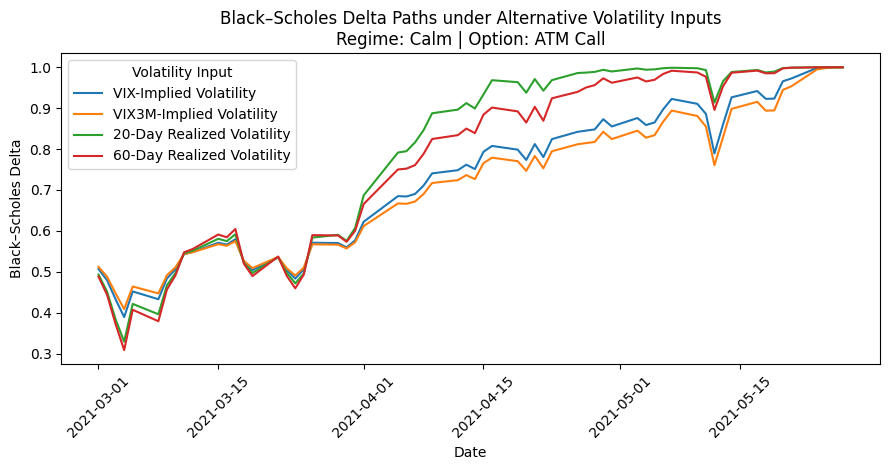

In [13]:

formal_title = (
    "Black–Scholes Delta Paths under Alternative Volatility Inputs\n"
    f"Regime: {sample_info['regime'].title()} | "
    f"Option: {sample_info['moneyness']} {sample_info['option_type'].title()}"
)

plt.figure(figsize=(9, 4.8))
for method in sample["vol_method"].unique():
    sub = sample[sample["vol_method"] == method]
    plt.plot(sub["date"], sub["delta"], label=vol_label_map.get(method, method))

plt.title(formal_title)
plt.xlabel("Date")
plt.ylabel("Black–Scholes Delta")
plt.legend(title="Volatility Input")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_delta_paths.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


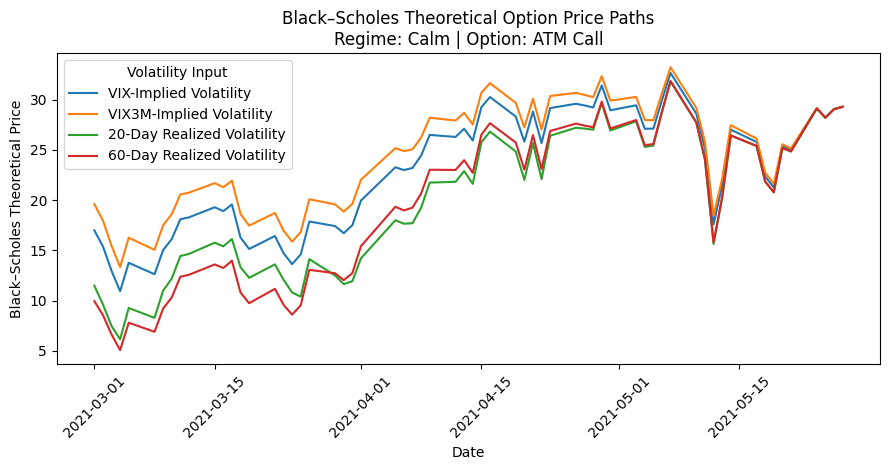

In [14]:

formal_title = (
    "Black–Scholes Theoretical Option Price Paths\n"
    f"Regime: {sample_info['regime'].title()} | "
    f"Option: {sample_info['moneyness']} {sample_info['option_type'].title()}"
)

plt.figure(figsize=(9, 4.8))
for method in sample["vol_method"].unique():
    sub = sample[sample["vol_method"] == method]
    plt.plot(sub["date"], sub["bs_price"], label=vol_label_map.get(method, method))

plt.title(formal_title)
plt.xlabel("Date")
plt.ylabel("Black–Scholes Theoretical Price")
plt.legend(title="Volatility Input")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_price_paths.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


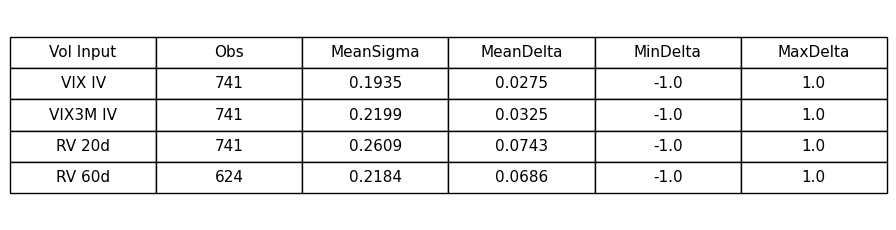

In [20]:
diagnostics_table = (
    bs_panel.groupby("vol_method")
    .agg(
        Obs=("delta", "count"),
        MeanSigma=("sigma", "mean"),
        MeanDelta=("delta", "mean"),
        MinDelta=("delta", "min"),
        MaxDelta=("delta", "max")
    )
    .reset_index()
)

label_map_short = {
    "iv_inception_vix": "VIX IV",
    "iv_inception_vix3m": "VIX3M IV",
    "rv_20d": "RV 20d",
    "rv_60d": "RV 60d"
}

diagnostics_table["vol_method"] = diagnostics_table["vol_method"].map(label_map_short)
diagnostics_table = diagnostics_table.rename(columns={"vol_method": "Vol Input"})

for col in ["MeanSigma", "MeanDelta", "MinDelta", "MaxDelta"]:
    diagnostics_table[col] = diagnostics_table[col].round(4)

diagnostics_table
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.axis("off")

tbl = ax.table(
    cellText=diagnostics_table.values,
    colLabels=diagnostics_table.columns,
    loc="center",
    cellLoc="center"
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.05, 1.65)

plt.tight_layout()
plt.savefig(FIG_DIR / "table_model_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:

report_summary = (
    bs_panel.groupby(["regime", "moneyness", "option_type", "vol_method"])
    .agg(
        mean_sigma=("sigma", "mean"),
        mean_delta=("delta", "mean"),
        sd_delta=("delta", "std"),
        mean_bs_price=("bs_price", "mean"),
        n_obs=("delta", "count")
    )
    .reset_index()
)

report_summary["vol_method_label"] = report_summary["vol_method"].map(vol_label_map)
report_summary.to_csv(TABLE_DIR / "bs_delta_summary.csv", index=False)

display(report_summary.head(20))


,regime,moneyness,option_type,vol_method,mean_sigma,mean_delta,sd_delta,mean_bs_price,n_obs,vol_method_label
0,calm,ATM,call,iv_inception_vix,0.233500,0.723634,0.180592,22.775460,63,VIX-Implied Volatility
1,calm,ATM,call,iv_inception_vix3m,0.267800,0.709678,0.168839,24.255942,63,VIX3M-Implied Volatility
2,calm,ATM,call,rv_20d,0.139658,0.787731,0.226650,19.800164,63,20-Day Realized Volatility
3,calm,ATM,call,rv_60d,0.148683,0.766657,0.218295,19.565579,63,60-Day Realized Volatility
4,calm,ATM,put,iv_inception_vix,0.233500,-0.274767,0.179677,7.894279,63,VIX-Implied Volatility
5,calm,ATM,put,iv_inception_vix3m,0.267800,-0.288724,0.167923,9.374761,63,VIX3M-Implied Volatility
6,calm,ATM,put,rv_20d,0.139658,-0.210670,0.225783,4.918983,63,20-Day Realized Volatility
7,calm,ATM,put,rv_60d,0.148683,-0.231745,0.217405,4.684398,63,60-Day Realized Volatility
8,calm,OTM,call,iv_inception_vix,0.233500,0.514911,0.166723,11.378959,63,VIX-Implied Volatility
9,calm,OTM,call,iv_inception_vix3m,0.267800,0.518135,0.148632,13.075376,63,VIX3M-Implied Volatility


## 8. Save deliverables

In [21]:

output_parquet = DATA_PATH / "bs_delta_panel.parquet"
output_csv = DATA_PATH / "bs_delta_panel.csv"
episode_summary_csv = TABLE_DIR / "episode_summary.csv"
summary_csv = TABLE_DIR / "bs_delta_summary.csv"
readme_path = DATA_PATH / "bs_delta_panel_README.md"
manifest_path = DATA_PATH / "modeling_outputs_manifest.txt"

bs_panel.to_parquet(output_parquet, index=False)
bs_panel.to_csv(output_csv, index=False)
episode_summary.to_csv(episode_summary_csv)
report_summary.to_csv(summary_csv, index=False)

readme_text = f"""# Black-Scholes Delta Panel

Generated by `black_scholes_model.ipynb`.

## Main handoff files
- `bs_delta_panel.parquet`
- `bs_delta_panel.csv`

## Unit of observation
One row = one option episode × one trading day × one volatility method.

## Key columns
- `episode_id`: option experiment identifier.
- `regime`: market regime label.
- `date`: trading date.
- `S`: SPY traded close price.
- `K`: option strike.
- `tau`: remaining time to maturity in years.
- `r`: daily risk-free rate input, decimal.
- `q`: continuous dividend-yield proxy.
- `sigma`: volatility input used for Black-Scholes.
- `bs_price`: theoretical Black-Scholes option value.
- `delta`: Black-Scholes delta.
- `option_type`: `call` or `put`.
- `moneyness`: ATM/OTM label from the episode file.
- `vol_method`: volatility specification. Current values: {sorted(bs_panel['vol_method'].unique().tolist())}.

## Report resources saved
Figures in `report_figures/`
Tables in `report_tables/`

## Handoff note
Use `delta` as the hedge ratio for the rebalancing simulation.
Filter by `vol_method` to compare hedging performance under different volatility assumptions.
"""

manifest_text = "\n".join([
    "MODEL HANDOFF FILES",
    str(output_parquet),
    str(output_csv),
    str(readme_path),
    "",
    "REPORT FIGURES",
    str(FIG_DIR / "fig_delta_paths.png"),
    str(FIG_DIR / "fig_price_paths.png"),
    str(FIG_DIR / "table_volatility_inputs.png"),
    str(FIG_DIR / "table_model_diagnostics.png"),
    "",
    "REPORT TABLE CSVS",
    str(TABLE_DIR / "table_volatility_inputs.csv"),
    str(TABLE_DIR / "table_model_diagnostics.csv"),
    str(TABLE_DIR / "bs_delta_summary.csv"),
    str(TABLE_DIR / "episode_summary.csv"),
])

readme_path.write_text(readme_text, encoding="utf-8")
manifest_path.write_text(manifest_text, encoding="utf-8")

print("Saved files:")
for p in [
    output_parquet, output_csv, episode_summary_csv, summary_csv,
    readme_path, manifest_path,
    FIG_DIR / "fig_delta_paths.png",
    FIG_DIR / "fig_price_paths.png",
    FIG_DIR / "table_volatility_inputs.png",
    FIG_DIR / "table_model_diagnostics.png",
]:
    print(" -", p)


Saved files:
 - C:\Users\elain\Downloads\5010-Project\data\output\bs_delta_panel.parquet
 - C:\Users\elain\Downloads\5010-Project\data\output\bs_delta_panel.csv
 - C:\Users\elain\Downloads\5010-Project\data\output\report_tables\episode_summary.csv
 - C:\Users\elain\Downloads\5010-Project\data\output\report_tables\bs_delta_summary.csv
 - C:\Users\elain\Downloads\5010-Project\data\output\bs_delta_panel_README.md
 - C:\Users\elain\Downloads\5010-Project\data\output\modeling_outputs_manifest.txt
 - C:\Users\elain\Downloads\5010-Project\data\output\report_figures\fig_delta_paths.png
 - C:\Users\elain\Downloads\5010-Project\data\output\report_figures\fig_price_paths.png
 - C:\Users\elain\Downloads\5010-Project\data\output\report_figures\table_volatility_inputs.png
 - C:\Users\elain\Downloads\5010-Project\data\output\report_figures\table_model_diagnostics.png


In [18]:

check = pd.read_parquet(DATA_PATH / "bs_delta_panel.parquet")
print("Reloaded shape:", check.shape)
display(check.head())

print("\nSaved figure files:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)

print("\nSaved table files:")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", p.name)


Reloaded shape: (2847, 19)


,episode_id,regime,date,S,K,tau,r,q,sigma,bs_price,delta,option_type,cp_flag,moneyness,vol_method,q_source,inception_date,expiration,S0
0,SPY_calm_C_ATM,calm,2021-03-01,389.579987,390.0,0.241096,0.00028,0.013122,0.2335,16.989992,0.506741,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
1,SPY_calm_C_ATM,calm,2021-03-02,386.540009,390.0,0.238356,0.00035,0.013122,0.2335,15.399808,0.479406,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
2,SPY_calm_C_ATM,calm,2021-03-03,381.420013,390.0,0.235616,0.00035,0.013122,0.2335,12.971057,0.432680,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
3,SPY_calm_C_ATM,calm,2021-03-04,376.700012,390.0,0.232877,0.00028,0.013122,0.2335,10.937231,0.389266,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987
4,SPY_calm_C_ATM,calm,2021-03-05,383.630005,390.0,0.230137,0.00028,0.013122,0.2335,13.758139,0.451908,call,C,ATM,iv_inception_vix,div_amount_in_window / S0 / T_years,2021-03-01,2021-05-28,389.579987



Saved figure files:
 - fig_delta_paths.png
 - fig_price_paths.png
 - table_model_diagnostics.png
 - table_volatility_inputs.png

Saved table files:
 - bs_delta_summary.csv
 - episode_summary.csv
 - table_model_diagnostics.csv
 - table_volatility_inputs.csv


## 9. Suggested team handoff message

I finished the Black–Scholes modeling layer. The main handoff file is `data/output/bs_delta_panel.parquet`, with one row per episode × trading day × volatility method. It includes theoretical option price, remaining maturity, risk-free rate, volatility input, and delta. Use `delta` directly for the rebalancing simulation, and compare results across `vol_method`. Formal figures and tables for the report are saved under `data/output/report_figures/` and `data/output/report_tables/`.